In [ ]:
!pip install scipy statsmodels

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("../dataset/Cleaned_Superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.describe().to_csv("../outputs/descriptive_statistics.csv")

In [7]:
df["Sales"].mean()

np.float64(229.85800083049827)

In [8]:
df["Sales"].median()

np.float64(54.489999999999995)

In [9]:
df["Sales"].mode()

0    12.96
Name: Sales, dtype: float64

In [10]:
df["Sales"].std()

np.float64(623.2451005086808)

In [11]:
df["Sales"].skew()

np.float64(12.97275234181623)

In [12]:
consumer = df[df["Segment"] == "Consumer"]["Sales"]
corporate = df[df["Segment"] == "Corporate"]["Sales"]

In [13]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(consumer, corporate)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.7463917427031926
P-Value: 0.4554521800582204


In [14]:
with open("../outputs/hypothesis_test_results.txt", "w") as f:
    f.write(f"T-Statistic: {t_stat}\n")
    f.write(f"P-Value: {p_value}\n")

In [16]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("P-Value:", p)

Chi-Square: 3.6619309383265723
P-Value: 0.7223155543986877


In [17]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Category"], df["Region"])

table

Region,Central,East,South,West
Category,,,,
Furniture,481,601,332,707
Office Supplies,1422,1712,995,1897
Technology,420,535,293,599


In [18]:
from scipy import stats
import numpy as np

confidence = 0.95

ci = stats.t.interval(
    confidence,
    len(df["Sales"]) - 1,
    loc=np.mean(df["Sales"]),
    scale=stats.sem(df["Sales"])
)

print(ci)

(np.float64(217.63747489897534), np.float64(242.0785267620212))


In [19]:
with open("../outputs/confidence_intervals.txt", "w") as f:
    f.write(str(ci))

In [20]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [21]:
df = df.set_index("Order Date")

df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2016-11-08,2,CA-2016-152156,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2016-06-12,3,CA-2016-138688,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2015-10-11,4,US-2015-108966,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2015-10-11,5,US-2015-108966,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [23]:
monthly_sales = df["Sales"].resample("ME").sum()

monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

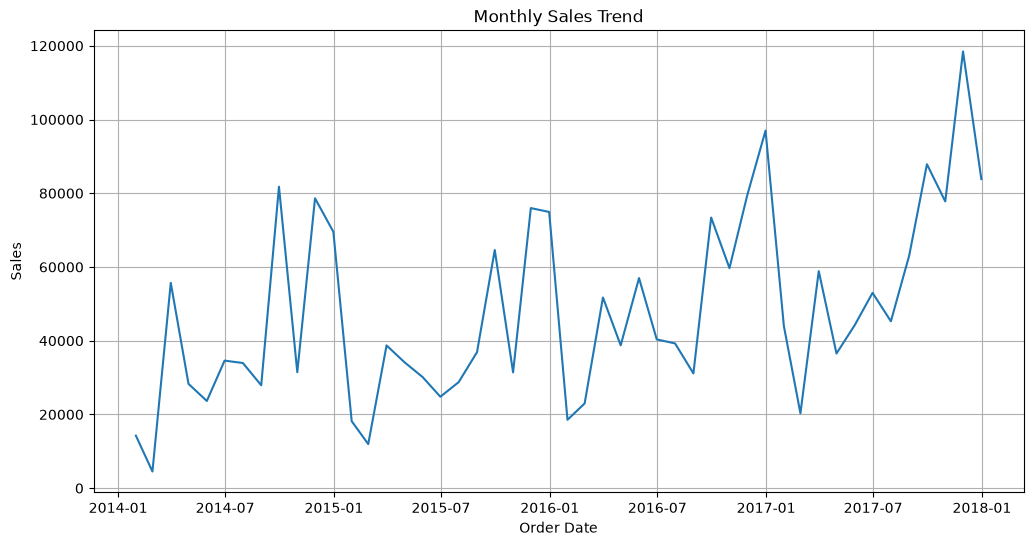

In [26]:
import pandas as pd
import matplotlib as pyplot
plt.figure(figsize=(12,6))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [27]:
monthly_sales.to_csv("../outputs/monthly_sales.csv")

In [29]:
!pip install statsmodels

  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmod

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

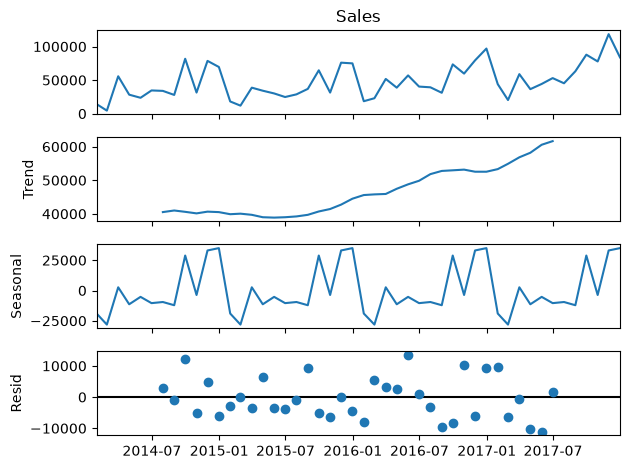

In [31]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

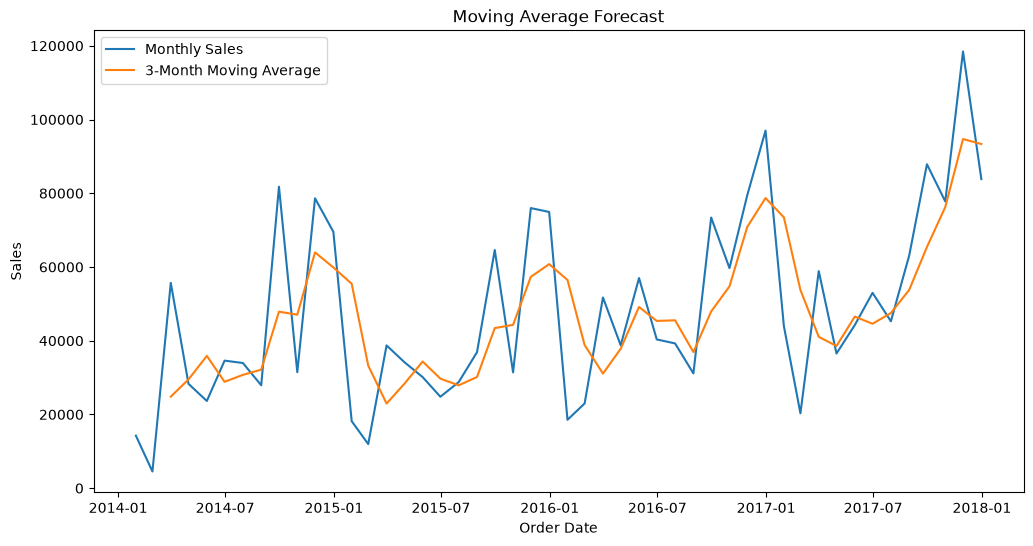

In [32]:
moving_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(moving_avg, label="3-Month Moving Average")

plt.title("Moving Average Forecast")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

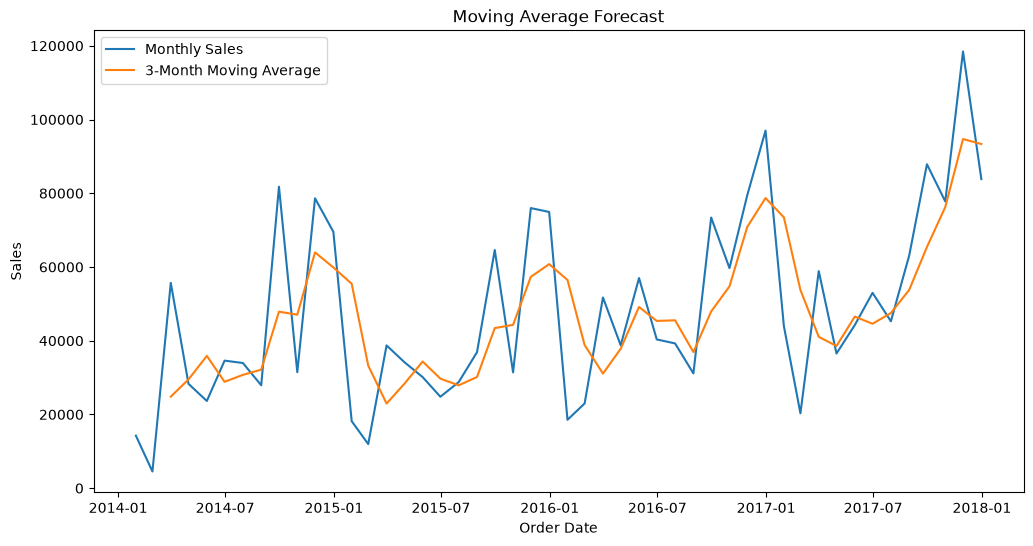

In [33]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(moving_avg, label="3-Month Moving Average")

plt.title("Moving Average Forecast")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()

plt.savefig("../outputs/forecast_plot.png")

plt.show()

In [10]:
cluster_data = df[["Sales", "Profit", "Quantity"]]

cluster_data.head()

,Sales,Profit,Quantity
Order Date,,,
2016-11-08,261.9600,41.9136,2
2016-11-08,731.9400,219.5820,3
2016-06-12,14.6200,6.8714,2
2015-10-11,957.5775,-383.0310,5
2015-10-11,22.3680,2.5164,2


In [11]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

NameError: name 'StandardScaler' is not defined

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA